# Post-Conflict Constitutional Moments — Analysis

The post-conflict variable is the strongest predictor of constitutional recognition of ethnocultural diversity — stronger than colonial heritage.

**Unit of analysis:** The *current constitution's* adoption context, not the country as an inherent property.

**Criterion:** Constitution adopted as a direct result of a negotiated peace process, post-war/post-genocide transition, or post-liberation state-building. Coups, authoritarian revisions, and routine amendments are excluded.

**Result:** 15/54 coded as post-conflict. Heritage + post-conflict explain 54.9% of variance (vs heritage alone 22.3%).

In [1]:
import json
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats

sns.set_theme(style='whitegrid', font='serif', palette='muted')
plt.rcParams.update({'figure.dpi': 150, 'savefig.dpi': 300, 'savefig.bbox': 'tight', 'font.family': 'serif'})

HC = {'francophone': '#4a5a9a', 'anglophone': '#9a3a4a', 'lusophone': '#2a7a5a', 'other': '#7a8088', 'mixed': '#7a8088'}
HL = {'francophone': 'Francophone', 'anglophone': 'Anglophone', 'lusophone': 'Lusophone', 'other': 'Autre'}
H_ORDER = ['francophone', 'anglophone', 'lusophone', 'other']

PROJECT = Path('..') if Path('../src/data.js').exists() else Path('.')
FIG_DIR = PROJECT / 'data' / 'figures'
FIG_DIR.mkdir(exist_ok=True)

with open(PROJECT / 'src' / 'data.js') as f:
    DATA = json.loads(f.read().split('const DATA = ')[1].rstrip(';\n'))
with open(PROJECT / 'scripts' / 'post_conflict_coding.json') as f:
    pc_coding = json.load(f)

FEATURES = DATA['features']
LABELS = DATA['feature_labels']

# Build DataFrame
rows = []
for row in DATA['feature_matrix']:
    c = row['PAYS']
    pc_info = pc_coding.get(c, {})
    rows.append({
        'country': c,
        'heritage': DATA['colonial_heritage'].get(c, 'other'),
        'post_conflict': pc_info.get('post_conflict', False) if isinstance(pc_info, dict) else pc_info,
        'const_year': pc_info.get('current_year') if isinstance(pc_info, dict) else None,
        'note': pc_info.get('note', '') if isinstance(pc_info, dict) else '',
        'total': sum(row[f] for f in FEATURES),
        **{f: row[f] for f in FEATURES}
    })
fm = pd.DataFrame(rows).set_index('country')
fm['pc_label'] = fm['post_conflict'].map({True: 'Post-conflit', False: 'Non-conflit'})

# Tier 1 subset
fa = fm[fm['heritage'].isin(['francophone', 'anglophone'])].copy()

print(f'Total: {len(fm)} countries, {fm["post_conflict"].sum()} post-conflict')
print(f'Tier 1: {len(fa)} countries (franco+anglo)')

Total: 54 countries, 15 post-conflict
Tier 1: 42 countries (franco+anglo)


## 1. Post-Conflict Coding Summary

In [2]:
# List all post-conflict constitutions with justification
pc_countries = fm[fm['post_conflict']].sort_values('total', ascending=False)
print(f'Post-conflict constitutions ({len(pc_countries)}/54):\n')
for name, row in pc_countries.iterrows():
    print(f'  {name:35s} [{row["heritage"]:12s}] score={row["total"]:2.0f}  year={row["const_year"]}  {row["note"]}')

# Crosstab
print('\nHeritage × post-conflict:')
print(pd.crosstab(fm['heritage'], fm['pc_label']))

Post-conflict constitutions (15/54):

  Kenya                               [anglophone  ] score=18  year=2010  Post-2007/2008 electoral violence (Kofi Annan mediation)
  Éthiopie                            [other       ] score=18  year=1994  Post-Derg — EPRDF armed liberation (1991)
  Soudan du Sud                       [anglophone  ] score=17  year=2011  Independence after Second Sudanese Civil War (CPA 2005)
  Ouganda                             [anglophone  ] score=16  year=1995  Post-NRM civil war victory (1986), constituent assembly
  Zimbabwe                            [anglophone  ] score=16  year=2013  Global Political Agreement (2008) power-sharing after electoral crisis
  Afrique du Sud                      [anglophone  ] score=16  year=1996  Post-apartheid negotiated transition (CODESA/MPNP)
  République démocratique du Congo    [francophone ] score=15  year=2006  Post-Second Congo War (Sun City agreement 2002)
  Somalie                             [other       ] score=15  

## 2. The 2×2 Interaction

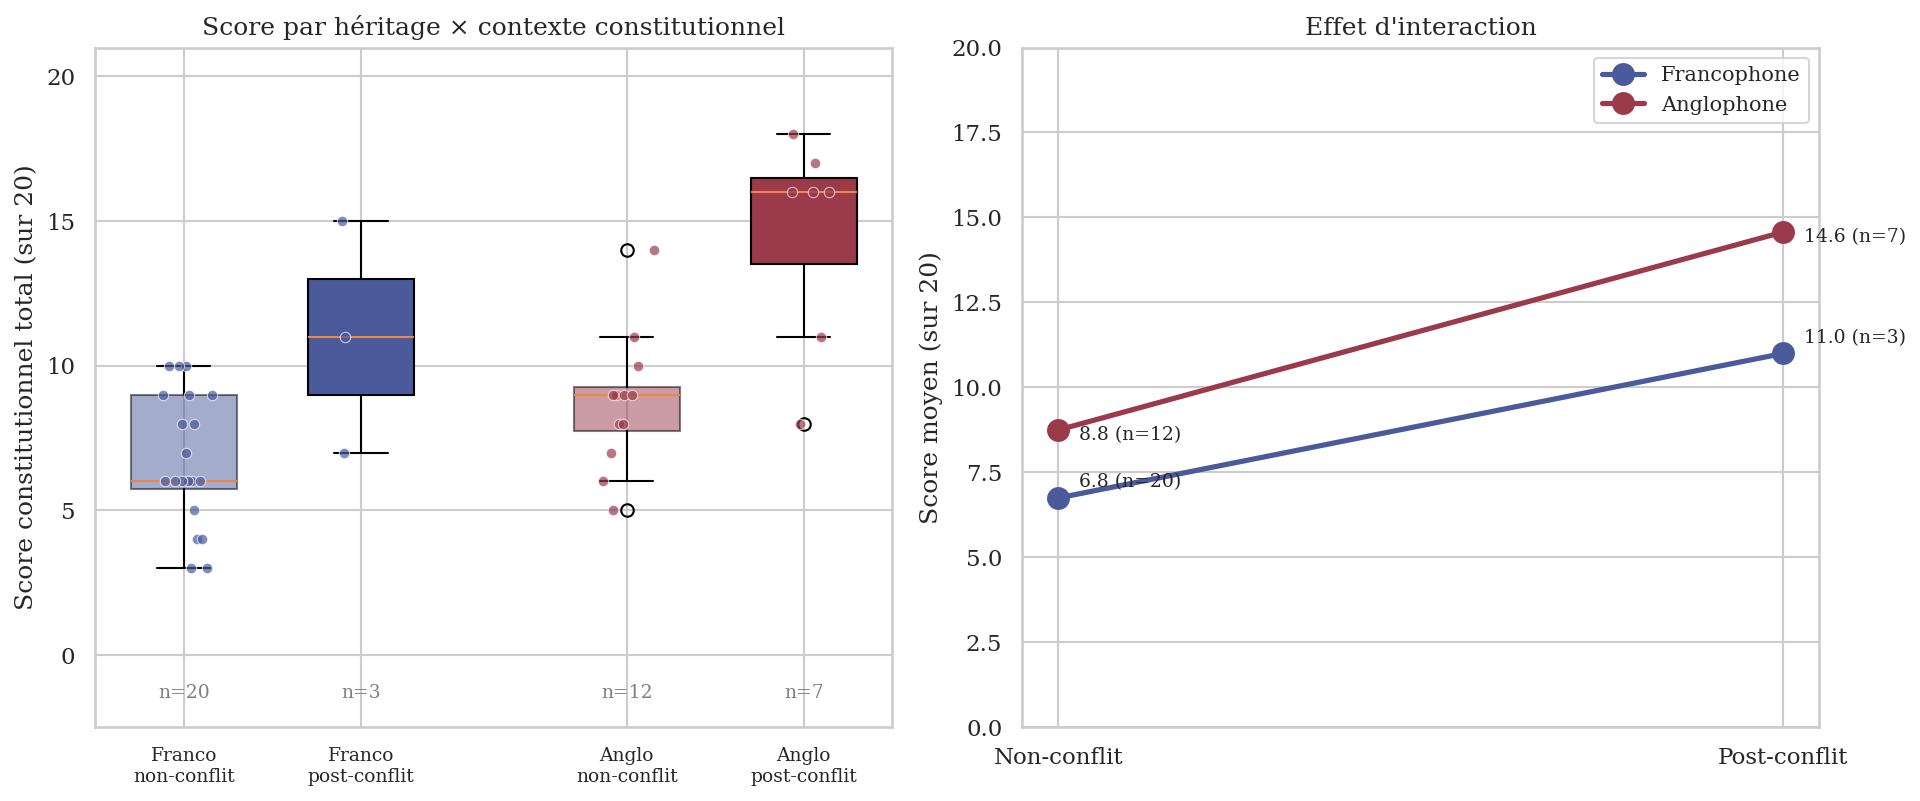

η² heritage alone:     0.223 (22.3%)
η² conflict alone:     0.455 (45.5%)
η² heritage+conflict:  0.549 (54.9%)


In [3]:
# FIGURE: 2×2 interaction plot (heritage × post-conflict)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.5))

# Left: box plot
groups = [
    ('Franco\nnon-conflit', fa[(fa['heritage']=='francophone') & (~fa['post_conflict'])]['total'], HC['francophone'], 0.5),
    ('Franco\npost-conflit', fa[(fa['heritage']=='francophone') & (fa['post_conflict'])]['total'], HC['francophone'], 1.0),
    ('Anglo\nnon-conflit', fa[(fa['heritage']=='anglophone') & (~fa['post_conflict'])]['total'], HC['anglophone'], 0.5),
    ('Anglo\npost-conflit', fa[(fa['heritage']=='anglophone') & (fa['post_conflict'])]['total'], HC['anglophone'], 1.0),
]

positions = [0, 1, 2.5, 3.5]
for i, (label, data, color, alpha) in enumerate(groups):
    bp = ax1.boxplot([data.values], positions=[positions[i]], widths=0.6, patch_artist=True)
    bp['boxes'][0].set_facecolor(color)
    bp['boxes'][0].set_alpha(alpha)
    # Individual points
    jitter = np.random.normal(0, 0.08, len(data))
    ax1.scatter([positions[i]] * len(data) + jitter, data.values, 
               c=color, s=25, alpha=0.7, edgecolors='white', linewidth=0.5, zorder=3)
    ax1.text(positions[i], -1.5, f'n={len(data)}', ha='center', fontsize=9, color='gray')

ax1.set_xticks(positions)
ax1.set_xticklabels([g[0] for g in groups], fontsize=9)
ax1.set_ylabel('Score constitutionnel total (sur 20)')
ax1.set_ylim(-2.5, 21)
ax1.set_title('Score par héritage × contexte constitutionnel', fontsize=12)

# Right: interaction line plot (means)
for h, color in [('francophone', HC['francophone']), ('anglophone', HC['anglophone'])]:
    means = []
    for pc in [False, True]:
        subset = fa[(fa['heritage']==h) & (fa['post_conflict']==pc)]
        means.append(subset['total'].mean() if len(subset) > 0 else np.nan)
    ax2.plot([0, 1], means, 'o-', color=color, linewidth=2.5, markersize=10, label=HL[h])
    for j, (m, pc) in enumerate(zip(means, [False, True])):
        n = len(fa[(fa['heritage']==h) & (fa['post_conflict']==pc)])
        if not np.isnan(m):
            ax2.annotate(f'{m:.1f} (n={n})', (j, m), fontsize=9, 
                        xytext=(10, -5 if h=='anglophone' else 5), textcoords='offset points')

ax2.set_xticks([0, 1])
ax2.set_xticklabels(['Non-conflit', 'Post-conflit'], fontsize=11)
ax2.set_ylabel('Score moyen (sur 20)')
ax2.set_title('Effet d\'interaction', fontsize=12)
ax2.legend(fontsize=10)
ax2.set_ylim(0, 20)

plt.tight_layout()
fig.savefig(FIG_DIR / 'post_conflict_interaction.pdf')
fig.savefig(FIG_DIR / 'post_conflict_interaction.png')
plt.show()

# Statistics
gm = fa['total'].mean()
ss_t = ((fa['total'] - gm)**2).sum()
ss_h = sum(len(fa[fa['heritage']==h]) * (fa[fa['heritage']==h]['total'].mean() - gm)**2 for h in ['francophone','anglophone'])
ss_pc = sum(len(fa[fa['post_conflict']==v]) * (fa[fa['post_conflict']==v]['total'].mean() - gm)**2 for v in [True, False])
fa['cell'] = fa['heritage'] + '_' + fa['post_conflict'].astype(str)
cell_m = fa.groupby('cell')['total'].mean()
ss_cells = sum(len(fa[fa['cell']==c]) * (cell_m[c] - gm)**2 for c in cell_m.index)

print(f'η² heritage alone:     {ss_h/ss_t:.3f} ({ss_h/ss_t*100:.1f}%)')
print(f'η² conflict alone:     {ss_pc/ss_t:.3f} ({ss_pc/ss_t*100:.1f}%)')
print(f'η² heritage+conflict:  {ss_cells/ss_t:.3f} ({ss_cells/ss_t*100:.1f}%)')

## 3. Per-Dimension Breakdown

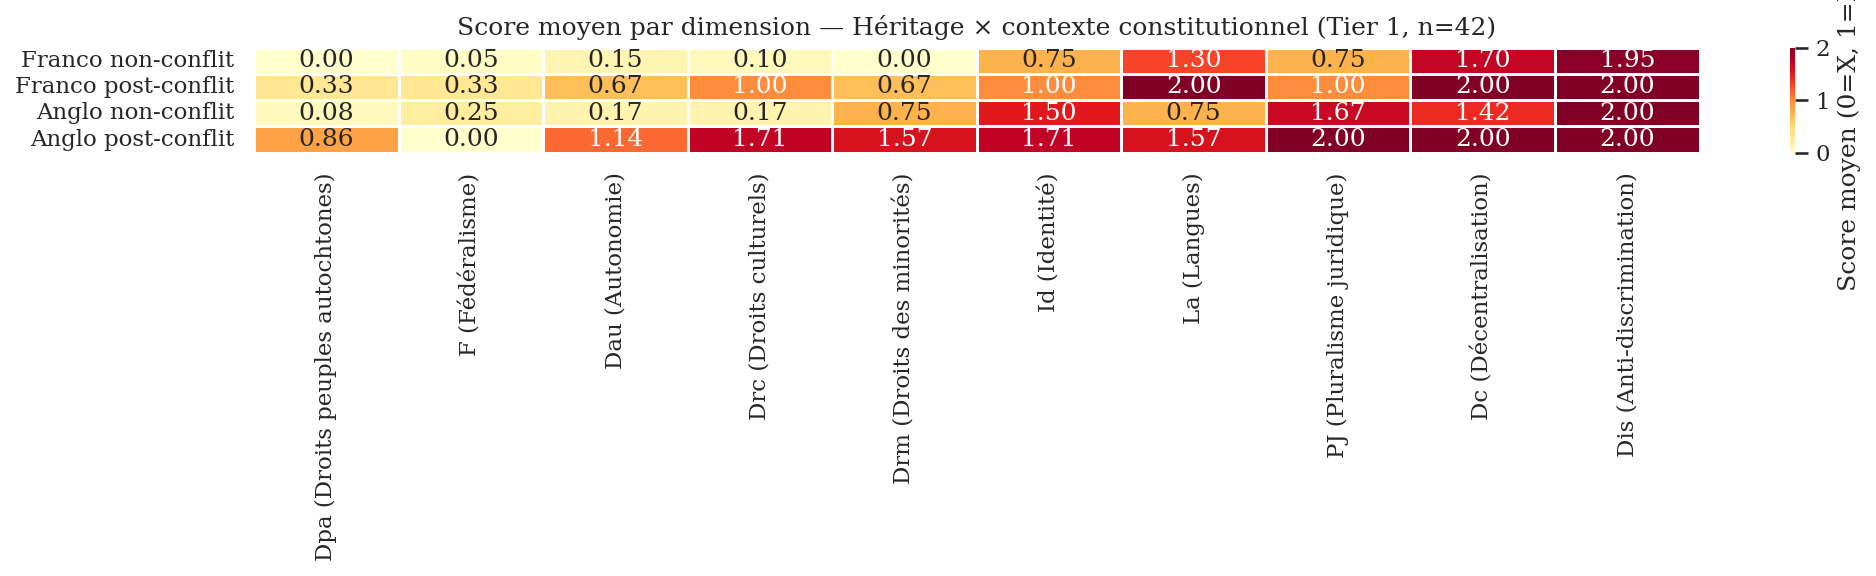

Per-dimension conflict effect (Tier 1, n=42):
Dim    F+conf    F+non   A+conf    A+non  Conflict p
Dpa      0.33     0.00     0.86     0.08      0.0000 ***
F        0.33     0.05     0.00     0.25      1.0000 ns
Dau      0.67     0.15     1.14     0.17      0.0004 ***
Drc      1.00     0.10     1.71     0.17      0.0000 ***
Drm      0.67     0.00     1.57     0.75      0.0004 ***
Id       1.00     0.75     1.71     1.50      0.0810 ns
La       2.00     1.30     1.57     0.75      0.0533 ns
PJ       1.00     0.75     2.00     1.67      0.0533 ns
Dc       2.00     1.70     2.00     1.42      0.0665 ns
Dis      2.00     1.95     2.00     2.00      0.6149 ns


In [4]:
# FIGURE: Per-dimension heatmap — 4 cells (heritage × conflict) × 10 dimensions
cells = [
    ('Franco non-conflit', fa[(fa['heritage']=='francophone') & (~fa['post_conflict'])]),
    ('Franco post-conflit', fa[(fa['heritage']=='francophone') & (fa['post_conflict'])]),
    ('Anglo non-conflit', fa[(fa['heritage']=='anglophone') & (~fa['post_conflict'])]),
    ('Anglo post-conflit', fa[(fa['heritage']=='anglophone') & (fa['post_conflict'])]),
]

cell_means = pd.DataFrame({label: subset[FEATURES].mean() for label, subset in cells}).T
cell_means.columns = [f'{f} ({LABELS[f]})' for f in FEATURES]

fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(cell_means, annot=True, fmt='.2f', cmap='YlOrRd', vmin=0, vmax=2,
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Score moyen (0=X, 1=P, 2=V)'})
ax.set_title('Score moyen par dimension — Héritage × contexte constitutionnel (Tier 1, n=42)', fontsize=12)
ax.set_ylabel('')

plt.tight_layout()
fig.savefig(FIG_DIR / 'post_conflict_dimensions.pdf')
fig.savefig(FIG_DIR / 'post_conflict_dimensions.png')
plt.show()

# Per-dimension conflict effect test (within Tier 1)
print('Per-dimension conflict effect (Tier 1, n=42):')
print(f'{"Dim":4s}  {"F+conf":>7s}  {"F+non":>7s}  {"A+conf":>7s}  {"A+non":>7s}  {"Conflict p":>10s}')
for f in FEATURES:
    fc = fa[(fa['heritage']=='francophone') & (fa['post_conflict'])][f].mean()
    fn = fa[(fa['heritage']=='francophone') & (~fa['post_conflict'])][f].mean()
    ac = fa[(fa['heritage']=='anglophone') & (fa['post_conflict'])][f].mean()
    an = fa[(fa['heritage']=='anglophone') & (~fa['post_conflict'])][f].mean()
    conf = fa[fa['post_conflict']][f].values
    noconf = fa[~fa['post_conflict']][f].values
    _, p = stats.mannwhitneyu(conf, noconf, alternative='two-sided')
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
    print(f'{f:4s}  {fc:7.2f}  {fn:7.2f}  {ac:7.2f}  {an:7.2f}  {p:10.4f} {sig}')

## 4. Preamble Rhetoric by Post-Conflict Status

In [5]:
# Do post-conflict preambles have more identity rhetoric?
with open(PROJECT / 'scripts' / 'country_mapping.json') as f:
    EN_TO_FR = json.load(f)
FR_TO_EN = {v: k for k, v in EN_TO_FR.items()}

PREAMBLE_DIR = PROJECT / 'data' / 'preamble_corpus'

SOV_KW = ['sovereignty', 'sovereign', 'unity', 'indivisible', 'territorial integrity', 'national unity', 'unitary']
ID_KW = ['people', 'peoples', 'ethnic', 'tribe', 'tribal', 'diversity', 'community', 'communities',
         'indigenous', 'minority', 'minorities', 'identity', 'tradition', 'cultural heritage', 'customary']

def count_kw(text, keywords):
    t = text.lower()
    return sum(len(re.findall(r'\b' + re.escape(kw) + r'\b', t)) for kw in keywords)

preamble_rows = []
for name, row in fm.iterrows():
    en_name = FR_TO_EN.get(name)
    if not en_name:
        continue
    # Find preamble file
    candidates = list(PREAMBLE_DIR.glob(f'{en_name.replace(" ", "_")}*.txt'))
    if not candidates:
        continue
    text = candidates[0].read_text(encoding='utf-8')
    n_words = len(text.split())
    if n_words < 20:
        continue
    preamble_rows.append({
        'country': name, 'heritage': row['heritage'], 'post_conflict': row['post_conflict'],
        'sov': count_kw(text, SOV_KW) / n_words * 1000,
        'id': count_kw(text, ID_KW) / n_words * 1000,
    })

pa = pd.DataFrame(preamble_rows)

# Compare
print('Preamble rhetoric by post-conflict status:')
for pc in [True, False]:
    subset = pa[pa['post_conflict'] == pc]
    label = 'Post-conflit' if pc else 'Non-conflit'
    print(f'  {label:15s} (n={len(subset)}): sovereignty={subset["sov"].mean():.1f}, identity={subset["id"].mean():.1f}')

# Within francophone only (Tier 1)
print('\nWithin francophone:')
for pc in [True, False]:
    subset = pa[(pa['heritage']=='francophone') & (pa['post_conflict']==pc)]
    label = 'Post-conflit' if pc else 'Non-conflit'
    if len(subset) > 0:
        print(f'  {label:15s} (n={len(subset)}): sovereignty={subset["sov"].mean():.1f}, identity={subset["id"].mean():.1f}')

Preamble rhetoric by post-conflict status:
  Post-conflit    (n=13): sovereignty=9.9, identity=13.7
  Non-conflit     (n=36): sovereignty=11.4, identity=14.4

Within francophone:
  Post-conflit    (n=3): sovereignty=11.4, identity=8.9
  Non-conflit     (n=20): sovereignty=13.3, identity=14.7


## 5. Summary

In [6]:
print('='*60)
print('POST-CONFLICT ANALYSIS SUMMARY')
print('='*60)
print(f'\n  Post-conflict constitutions: {fa["post_conflict"].sum()}/{len(fa)} (Tier 1)')
print(f'  Post-conflict mean score: {fa[fa["post_conflict"]]["total"].mean():.1f}/20')
print(f'  Non-conflict mean score:  {fa[~fa["post_conflict"]]["total"].mean():.1f}/20')
print(f'  Mann-Whitney p = {stats.mannwhitneyu(fa[fa["post_conflict"]]["total"], fa[~fa["post_conflict"]]["total"]).pvalue:.4f}')
print(f'\n  η² heritage alone:     {ss_h/ss_t:.3f} ({ss_h/ss_t*100:.1f}%)')
print(f'  η² conflict alone:     {ss_pc/ss_t:.3f} ({ss_pc/ss_t*100:.1f}%)')
print(f'  η² heritage+conflict:  {ss_cells/ss_t:.3f} ({ss_cells/ss_t*100:.1f}%)')
print(f'\n  Key thesis implication:')
print(f'  Post-conflict constitutional moments drive recognition of sub-state')
print(f'  peoples more than inherited legal tradition. This supports the functional')
print(f'  criterion: recognition emerges from political necessity, not from')
print(f'  doctrinal tradition alone.')
print(f'\n  Figures: {list(FIG_DIR.glob("post_conflict_*"))}')